In [1]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt

import scipy.io as sio

In [2]:
def _maybe_transpose(a):
    # For MATLAB v7.3 via h5py, 2D arrays often come out transposed
    if a.ndim == 2:
        return a.T
    return a

def _to_complex_if_compound(arr):
    # MATLAB v7.3 complex arrays can appear as compound dtype with fields ('real','imag')
    if hasattr(arr.dtype, "fields") and arr.dtype.fields is not None:
        fields = arr.dtype.fields
        if "real" in fields and "imag" in fields:
            return arr["real"] + 1j * arr["imag"]
    return arr

def load_mat_var(path, varname="D"):
    """
    Returns numpy array for variable `varname` from a MATLAB .mat file.
    Supports both -v7.2 (scipy.io.loadmat) and -v7.3 (h5py).
    """
    try:
        md = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
        if varname not in md:
            keys = [k for k in md.keys() if not k.startswith("__")]
            raise KeyError(f"'{varname}' not found. Keys: {keys}")
        arr = np.asarray(md[varname])
        return arr
    except NotImplementedError:
        # Likely MATLAB -v7.3
        import h5py
        with h5py.File(path, "r") as f:
            if varname not in f:
                keys = list(f.keys())
                raise KeyError(f"'{varname}' not found in HDF5. Keys: {keys}")
            ds = f[varname]
            arr = np.array(ds)
            arr = _maybe_transpose(arr)
            arr = _to_complex_if_compound(arr)
            return arr

In [9]:
RESULT_DIR = "linear_wave_ssm_results/semi_implicit"
pattern = os.path.join(
    RESULT_DIR,
    "semi_implicit_bound40_6hr_damp_0_diff_0_wn_*_latbnd_60_dlat_2_rigidlid.mat"
)

files = sorted(glob.glob(pattern))
print("Found", len(files), "files")

def parse_wn(fname):
    m = re.search(r"_wn_(\d+)_", os.path.basename(fname))
    if not m:
        raise ValueError(f"Cannot parse wn from: {fname}")
    return int(m.group(1))

# Load
data_by_wn = {}
for f in files:
    wn = parse_wn(f)
    D = load_mat_var(f, "D")   # shape (N,3)
    D = np.atleast_2d(D)
    mu = D[:, 0].astype(np.complex128, copy=False)
    growth = np.real(D[:, 1])  # per day (already computed in MATLAB)
    freq = np.real(D[:, 2])    # cycles/day
    data_by_wn[wn] = {"mu": mu, "growth": growth, "freq": freq}

wns = sorted(data_by_wn.keys())
print("Loaded wavenumbers:", wns[:5], "...", wns[-5:])

Found 41 files
Loaded wavenumbers: [0, 1, 2, 3, 4] ... [36, 37, 38, 39, 40]


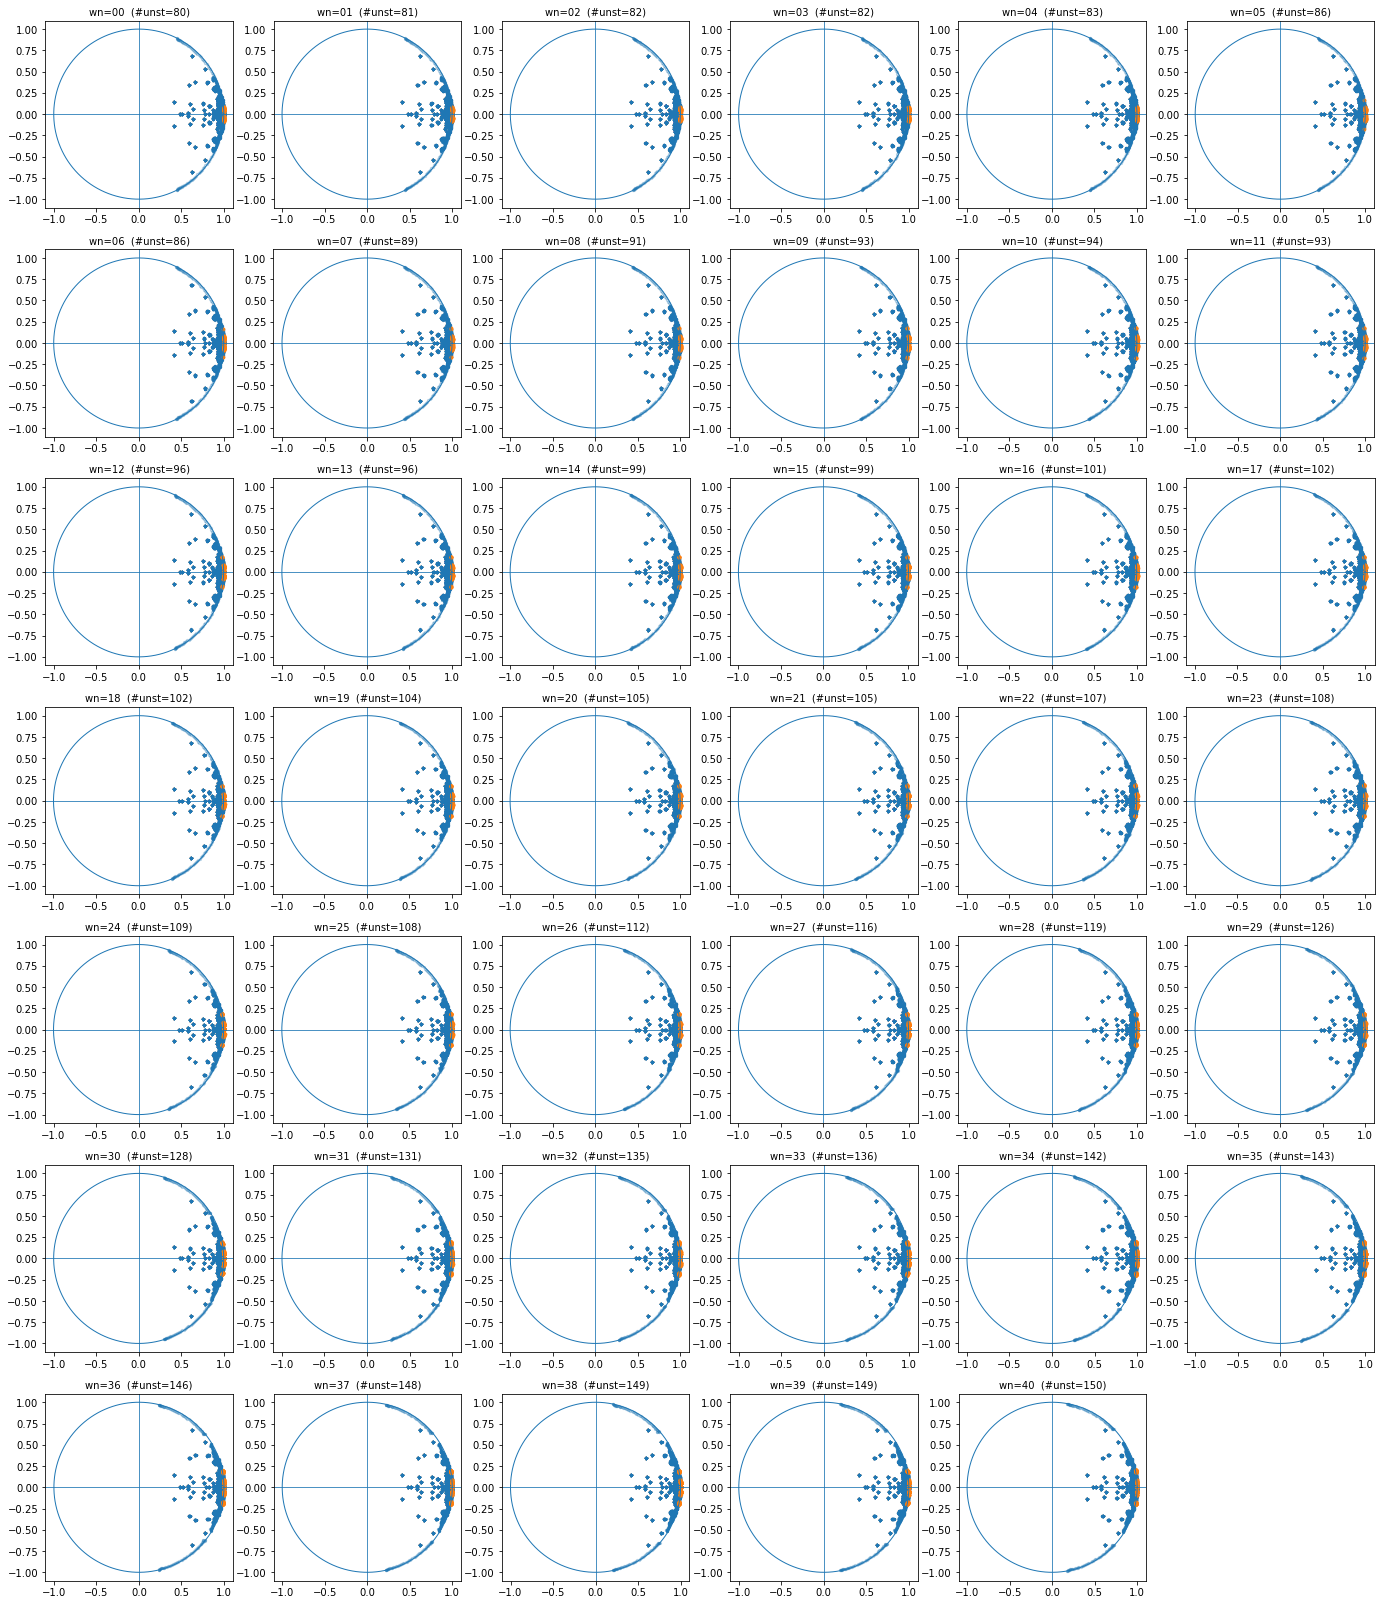

In [10]:
n = len(wns)
ncols = 6
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 3.2*nrows))
axes = np.atleast_1d(axes).ravel()

theta = np.linspace(0, 2*np.pi, 400)
uc_x, uc_y = np.cos(theta), np.sin(theta)

for ax, wn in zip(axes, wns):
    mu = data_by_wn[wn]["mu"]
    growth = data_by_wn[wn]["growth"]

    # stable vs unstable highlight using growth > 0 (equivalently |mu|>1 if consistent)
    stable = growth <= 0
    unstable = growth > 0

    ax.scatter(mu.real[stable],   mu.imag[stable],   s=5, alpha=0.25)
    ax.scatter(mu.real[unstable], mu.imag[unstable], s=8, alpha=0.9)

    ax.plot(uc_x, uc_y, linewidth=1)  # unit circle
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"wn={wn:02d}  (#unst={unstable.sum()})", fontsize=10)

for ax in axes[len(wns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Plotted points: 295 (growth_min=0.6)


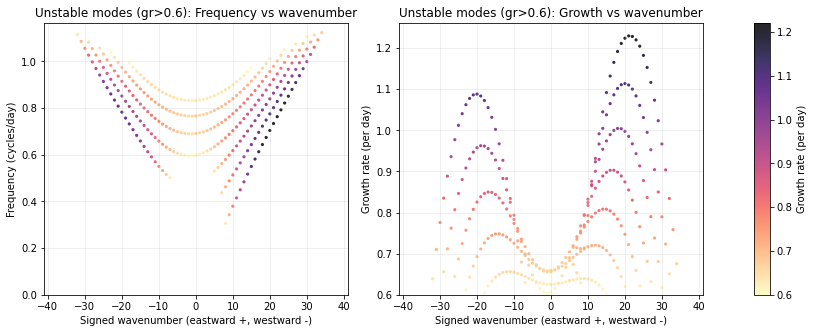

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

growth_min = 0.6
cmap_name = "magma_r"
marker_size = 10
alpha = 0.85
vmax_percentile = 99

xs, freq_pos, growths = [], [], []

for wn in sorted(data_by_wn.keys()):
    g = np.asarray(data_by_wn[wn]["growth"])
    f = np.asarray(data_by_wn[wn]["freq"])

    unstable = g > growth_min
    if not np.any(unstable):
        continue

    g_u = g[unstable]
    f_u = f[unstable]
    x_u = np.where(f_u < 0, +wn, -wn)

    xs.append(x_u)
    freq_pos.append(np.abs(f_u))
    growths.append(g_u)

xs = np.concatenate(xs) if xs else np.array([])
freq_pos = np.concatenate(freq_pos) if freq_pos else np.array([])
growths = np.concatenate(growths) if growths else np.array([])

print(f"Plotted points: {growths.size} (growth_min={growth_min})")

if growths.size > 0:
    wn_max = max(data_by_wn.keys())

    vmin = growth_min
    vmax = np.percentile(growths, vmax_percentile)
    if vmax <= vmin:
        vmax = growths.max()

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    fig = plt.figure(figsize=(13, 5))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.25)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharex=ax0)
    cax = fig.add_subplot(gs[0, 2])

    sc0 = ax0.scatter(xs, freq_pos, c=growths, cmap=cmap, norm=norm,
                     s=marker_size, alpha=alpha, linewidths=0)
    ax0.set_xlabel("Signed wavenumber (eastward +, westward -)")
    ax0.set_ylabel("Frequency (cycles/day)")
    ax0.set_title(f"Unstable modes (gr>{growth_min}): Frequency vs wavenumber")
    ax0.set_xlim(-wn_max - 1, wn_max + 1)
    ax0.set_ylim(bottom=0)              # <-- left panel starts at 0
    ax0.grid(True, alpha=0.25)

    sc1 = ax1.scatter(xs, growths, c=growths, cmap=cmap, norm=norm,
                     s=marker_size, alpha=alpha, linewidths=0)
    ax1.set_xlabel("Signed wavenumber (eastward +, westward -)")
    ax1.set_ylabel("Growth rate (per day)")
    ax1.set_title(f"Unstable modes (gr>{growth_min}): Growth vs wavenumber")
    ax1.set_xlim(-wn_max - 1, wn_max + 1)
    ax1.set_ylim(bottom=growth_min)     # <-- right panel starts at threshold
    ax1.grid(True, alpha=0.25)

    cb = fig.colorbar(sc0, cax=cax)
    cb.set_label("Growth rate (per day)")

    plt.show()